<a href="https://colab.research.google.com/github/ajayrfhp/LearningDeepLearning/blob/main/swishGelu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

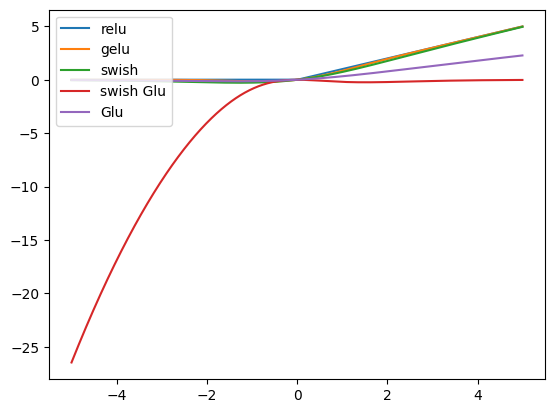

In [41]:
from numpy._core.fromnumeric import var
from numpy import mean
x = torch.arange(-5, 5, 0.01)

def relu(x):
  return torch.clamp_min(x, 0)

def gelu(x, normal):
   return x * normal.cdf(x)

def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

def swish(x):
  return x / (1 + torch.exp(-x))

def glu(x):
  s = (1 + torch.exp(-x))
  w_g = torch.randn((1, 1), requires_grad=True)
  w_v = torch.randn((1,1 ), requires_grad=True)
  g = x * w_g
  v = x * w_v

  return sigmoid(g) * v


def swish_gelu(x, model_dim=1000, gate_dim=64):
  w_g = torch.randn((1, 1), requires_grad=True)
  w_v = torch.randn((1,1 ), requires_grad=True)
  g = x * w_g
  v = x * w_v
  return swish(g) * v



y1 = relu(x)
normal = torch.distributions.Normal(loc=0, scale=1)
y2 = gelu(x, normal)
y3 = swish(x)
y4 = swish_gelu(x)
y5 = glu(x)
plt.plot(x, y1, label='relu')
plt.plot(x, y2, label='gelu')
plt.plot(x, y3, label='swish')
plt.plot(x, y4.detach().numpy().squeeze(), label='swish Glu')
plt.plot(x, y5.detach().numpy().squeeze(), label='Glu')
plt.legend(loc='upper left')
plt.show()